<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>
 
# **Algoritmos y Programación III**
**Proyecto final — Clasificación de calidad de frutas**
 
---
 
- **Martinez Vasquez Luna Catalina — A00401964**
- **Mosquera Daza Renzo Fernando — A00401681**
- **Tobar Gómez Valentina — A00401749**
 
---
 
# Notebook 04 — Modelo de Deep Learning: Red Neuronal Convolucional (CNN)

## 1. Propósito
 
El propósito de este notebook es desarrollar y evaluar un modelo de aprendizaje profundo (CNN). **Importante:** a diferencia de los modelos tradicionales entrenados previamente sobre vectores de píxeles aplanados, las CNN aprovechan la estructura espacial de las imágenes para aprender automáticamente características visuales relevantes como bordes, texturas, manchas y formas permitiendo una representación más adecuada del contenido visual y un mejor desempeño en tareas de clasificación.

**Validación cruzada:** Para seleccionar la mejor configuración del modelo, se entrenaron varias variantes de la arquitectura modificando hiperparámetros como el número de filtros, la tasa de dropout y la tasa de aprendizaje. Cada variante se evaluó sobre un conjunto de validación fijo y la de mejor desempeño fue utilizada para la evaluación final en el conjunto de prueba.

## 2. Importación de librerías

Cargamos las librerías para entrenar el modelo, ajustar hiperparámetros y guardar el modelo que usará la aplicación.

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    cohen_kappa_score,
    ConfusionMatrixDisplay,
)

from IPython.display import display

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 3. Rutas y parámetros
 
Usamos exactamente los mismos archivos que produjo el Notebook 02,
por lo que la partición train/val/test es idéntica a la de los modelos ML.
Esto hace que la comparación final de los cuatro modelos sea justa:
todos se evalúan sobre el mismo test set.
 
El tamaño de imagen se fija en **128×128**, el mismo que definió el Notebook 02
cuando guardó las imágenes procesadas. Los modelos ML del Notebook 03 usaron 48×48
para reducir el costo computacional del SVM; la CNN sí puede aprovechar la resolución
completa porque las convoluciones son eficientes en espacio.

In [2]:
PROJECT_ROOT   = Path.cwd().parent
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
MODELS_DIR     = PROJECT_ROOT / "models"
FIGURES_DIR    = PROJECT_ROOT / "results" / "figures"
TABLES_DIR     = PROJECT_ROOT / "results" / "tables"
 
TRAIN_PATH = ANNOTATIONS_DIR / "train_metadata.csv"
VAL_PATH   = ANNOTATIONS_DIR / "val_metadata.csv"
TEST_PATH  = ANNOTATIONS_DIR / "test_metadata.csv"
 
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS     = 40
QUALITY_LABELS = ["bad", "regular", "good"]
SIZE_LABELS    = ["small", "medium", "large"]
 
for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
 
print("Proyecto:", PROJECT_ROOT)
print(f"Imagen de entrada: {IMG_SIZE} x {IMG_SIZE} x 3")
print(f"Batch size: {BATCH_SIZE} | Épocas máximas: {EPOCHS}")

Proyecto: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3
Imagen de entrada: 128 x 128 x 3
Batch size: 32 | Épocas máximas: 40


## 4. Carga de metadatos y construcción de arrays
 
Cargamos los CSV de metadatos del Notebook 02 y leemos cada imagen
desde `processed_relative_path`. El preprocesamiento es idéntico al
que verá la aplicación en producción:
 
1. Abrir en RGB con corrección EXIF.
2. Redimensionar con padding blanco a 128×128 (`ImageOps.pad`),
   preservando el aspect ratio de la fruta.
3. Normalizar al rango **[0, 1]** dividiendo entre 255.

In [3]:
def read_metadata(path, split_name):
    if not path.exists():
        raise FileNotFoundError(
            f"No existe {path}. Ejecuta primero el Notebook 02."
        )
    df = pd.read_csv(path)
    df["split"] = split_name
    return df
 
 
def load_images(df, img_size=IMG_SIZE):
    """
    Lee las imágenes listadas en df["processed_relative_path"],
    las redimensiona a img_size x img_size con padding blanco y
    devuelve un array float32 en [0, 1] de forma (N, H, W, 3).
    """
    imgs = []
    for rel_path in df["processed_relative_path"]:
        abs_path = PROJECT_ROOT / Path(str(rel_path).replace("\\\\", "/").strip())
        with Image.open(abs_path) as img:
            img = ImageOps.exif_transpose(img).convert("RGB")
            img = ImageOps.pad(
                img,
                (img_size, img_size),
                color=(255, 255, 255),
                centering=(0.5, 0.5),
            )
        imgs.append(np.asarray(img, dtype="float32"))
    return np.stack(imgs) / 255.0
 
 
train_df = read_metadata(TRAIN_PATH, "train")
val_df   = read_metadata(VAL_PATH,   "val")
test_df  = read_metadata(TEST_PATH,  "test")
 
print("Cargando imágenes de entrenamiento…")
X_train = load_images(train_df)
print("Cargando imágenes de validación…")
X_val   = load_images(val_df)
print("Cargando imágenes de prueba…")
X_test  = load_images(test_df)
 
print(f"\\nX_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Rango de valores: [{X_train.min():.2f}, {X_train.max():.2f}]")

Cargando imágenes de entrenamiento…
Cargando imágenes de validación…
Cargando imágenes de prueba…
\nX_train : (3744, 128, 128, 3)  dtype=float32
X_val   : (1248, 128, 128, 3)
X_test  : (1249, 128, 128, 3)
Rango de valores: [0.00, 1.00]


In [4]:
# Etiquetas
y_train_quality = train_df["quality_label"].astype(str).values
y_val_quality   = val_df["quality_label"].astype(str).values
y_test_quality  = test_df["quality_label"].astype(str).values
 
y_train_size = train_df["size_label"].astype(str).values
y_val_size   = val_df["size_label"].astype(str).values
y_test_size  = test_df["size_label"].astype(str).values
 
# Convertimos las etiquetas a enteros usando el orden fijo de las listas.
quality_to_int = {c: i for i, c in enumerate(QUALITY_LABELS)}
size_to_int    = {c: i for i, c in enumerate(SIZE_LABELS)}
 
y_train_q_int = np.array([quality_to_int[l] for l in y_train_quality])
y_val_q_int   = np.array([quality_to_int[l] for l in y_val_quality])
y_test_q_int  = np.array([quality_to_int[l] for l in y_test_quality])
 
y_train_s_int = np.array([size_to_int[l] for l in y_train_size])
y_val_s_int   = np.array([size_to_int[l] for l in y_val_size])
y_test_s_int  = np.array([size_to_int[l] for l in y_test_size])
 
print("Distribución quality — train:")
for cls, n in zip(QUALITY_LABELS,
                  np.bincount(y_train_q_int, minlength=3)):
    print(f"  {cls}: {n}")
 
print("\\nDistribución size — train:")
for cls, n in zip(SIZE_LABELS,
                  np.bincount(y_train_s_int, minlength=3)):
    print(f"  {cls}: {n}")

Distribución quality — train:
  bad: 618
  regular: 2110
  good: 1016
\nDistribución size — train:
  small: 1250
  medium: 1249
  large: 1245


## 5. Arquitectura de la CNN
 
### Fundamento matemático
 
La operación central de la CNN es la **convolución discreta 2D**:
 
$$
(I * K)(i,j) = \sum_{m} \sum_{n} I(i + m,\; j + n) \cdot K(m,n)
$$
 
Aquí $I$ es la imagen (o el mapa de características de la capa anterior)
y $K$ es el filtro aprendido. En cada posición $(i,j)$ el filtro produce
un único valor que resume la presencia del patrón $K$ en esa vecindad.
 
La red aprende muchos filtros simultáneamente (32, 64, 128),
cada uno sensible a un patrón diferente donde algunos detectarán bordes,
otros manchas oscuras, otros texturas rugosas.
 
### Estructura de la CNN
 
La arquitectura implementada está compuesta por tres bloques convolucionales seguidos de una etapa de clasificación. Cada bloque combina una capa convolucional para la extracción de características, una capa de normalización (Batch Normalization) para estabilizar el entrenamiento y una capa de agrupamiento (Max Pooling) para reducir progresivamente la dimensionalidad espacial de la imagen.

| Etapa | Operación | Dimensión de salida |
|---|---|---|
| Entrada | Imagen RGB | 128 × 128 × 3 |
| Bloque 1 | Conv2D (32 filtros, 3×3, ReLU) | 128 × 128 × 32 |
| Bloque 1 | Batch Normalization | 128 × 128 × 32 |
| Bloque 1 | MaxPooling2D (2×2) | 64 × 64 × 32 |
| Bloque 2 | Conv2D (64 filtros, 3×3, ReLU) | 64 × 64 × 64 |
| Bloque 2 | Batch Normalization | 64 × 64 × 64 |
| Bloque 2 | MaxPooling2D (2×2) | 32 × 32 × 64 |
| Bloque 3 | Conv2D (128 filtros, 3×3, ReLU) | 32 × 32 × 128 |
| Bloque 3 | Batch Normalization | 32 × 32 × 128 |
| Bloque 3 | MaxPooling2D (2×2) | 16 × 16 × 128 |
| Clasificador | Flatten | 32 768 |
| Clasificador | Dense (128 neuronas, ReLU) | 128 |
| Clasificador | Dropout (0.5) | 128 |
| Salida | Dense (3 neuronas, Softmax) | 3 probabilidades |

 
* **Batch Normalization:** estabiliza las activaciónes de la red durante el entrenamiento, favoreciendo una convergencia más rápida y estable.
* **Dropout (0.5):** desactiva aleatoriamente una parte de las neuronas durante el entrenamiento para reducir el riesgo de sobreajuste y mejorar la capacidad de generalización.
* **Capa de salida Softmax:** se utiliza una capa de tres neuronas con función de activación softmax para obtener una distribución de probabilidades sobre las tres clases posibles.
* **Función de pérdida:** se emplea sparse_categorical_crossentropy, adecuada para problemas de clasificación multiclase cuando las etiquetas están codificadas como enteros.

In [5]:
def build_model(num_classes, filters=(32, 64, 128),
                dense_units=128, dropout_rate=0.5,
                learning_rate=1e-3):
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    features = layers.Conv2D(filters[0], (3, 3), activation="relu",
                             padding="same")(inputs)
    features = layers.BatchNormalization()(features)
    features = layers.MaxPooling2D((2, 2))(features)

    features = layers.Conv2D(filters[1], (3, 3), activation="relu",
                             padding="same")(features)
    features = layers.BatchNormalization()(features)
    features = layers.MaxPooling2D((2, 2))(features)

    features = layers.Conv2D(filters[2], (3, 3), activation="relu",
                             padding="same")(features)
    features = layers.BatchNormalization()(features)
    features = layers.MaxPooling2D((2, 2))(features)

    features = layers.Flatten()(features)
    features = layers.Dense(dense_units, activation="relu")(features)
    features = layers.Dropout(dropout_rate)(features)
    outputs = layers.Dense(num_classes, activation="softmax")(features)

    cnn_model = Model(inputs=inputs, outputs=outputs)
    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return cnn_model

demo_model = build_model(num_classes=3)
demo_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,963 (16.36 MB)

 Trainable params: 4,288,515 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Exploración de hiperparámetros
 
Con el fin de identificar la configuración más adecuada, entrenamos 3 variantes de la arquitectura modificando hiperparámetros como el número de filtros, la tasa de dropout y la tasa de aprendizaje. Cada variante fue evaluada sobre el conjunto de validación y seleccionamos la de mejor desempeño (*val_accuracy*) para cada una de las tareas de clasificación.
 
| Variante | Filtros | Dropout | Learning rate | Descripción |
|---|---|---:|---:|---|
| A | 32 / 64 / 128 | 0.5 | 1e-3 | Configuración base |
| B | 32 / 64 / 128 | 0.6 | 5e-4 | Mayor regularización |
| C | 64 / 128 / 256 | 0.5 | 1e-3 | Mayor capacidad de representación |

Hacemos esto **por separado para cada tarea** (quality y size),
porque son problemas distintos y podrían tener mejores hiperparámetros distintos.

In [6]:
VARIANTS = {
    "A_base": dict(
        filters=(32, 64, 128),
        dense_units=128,
        dropout_rate=0.5,
        learning_rate=1e-3,
        description="Base",
    ),
    "B_mas_regularizacion": dict(
        filters=(32, 64, 128),
        dense_units=128,
        dropout_rate=0.6,
        learning_rate=5e-4,
        description="Más regularización",
    ),
    "C_mas_capacidad": dict(
        filters=(64, 128, 256),
        dense_units=256,
        dropout_rate=0.5,
        learning_rate=1e-3,
        description="Mayor capacidad de representación",
    ),
}

print("Variantes a entrenar:")
for variant_key, variant_data in VARIANTS.items():
    print(f"  {variant_key}: {variant_data['description']}")


Variantes a entrenar:
  A_base: Base
  B_mas_regularizacion: Más regularización
  C_mas_capacidad: Mayor capacidad de representación


Algunos de los callbacks implementados: 

* EarlyStopping: detiene el entrenamiento si val_loss no mejora en 8 épocas y restaura los mejores pesos, esto evita sobreajuste por entrenar demasiadas épocas.
* ReduceLROnPlateau: reduce la tasa de aprendizaje a la mitad si val_loss no mejora en 4 épocas, lo cual ayuda al modelo a converger más suave y preciso cerca del mínimo.

In [7]:
def train_variant(x_train_data, y_train_data, x_val_data, y_val_data,
                  variant_key, variant_data, target_name,
                  epochs=EPOCHS, batch_size=BATCH_SIZE):
    print(f"\n{'='*60}")
    print(f"  Tarea: {target_name}  |  Variante: {variant_key}")
    print(f"  {variant_data['description']}")
    print(f"{'='*60}")

    model_params = {
        key: value for key, value in variant_data.items()
        if key != "description"
    }
    trained_model = build_model(
        num_classes=len(np.unique(y_train_data)),
        **model_params
    )

    callback_list = [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    training_history = trained_model.fit(
        x_train_data, y_train_data,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val_data, y_val_data),
        callbacks=callback_list,
        verbose=1,
    )

    best_val_acc = max(training_history.history["val_accuracy"])
    best_val_loss = min(training_history.history["val_loss"])
    print(f"\n  → Mejor val_accuracy: {best_val_acc:.4f} | "
          f"Mejor val_loss: {best_val_loss:.4f}")

    return trained_model, training_history


## 7. Entrenamiento para calidad (`quality_label`)
 
Entrenamos las tres variantes para la tarea de clasificar calidad
(bad / regular / good) y comparamos sus curvas de validación.

In [8]:
quality_histories = {}
quality_models = {}

for quality_variant_key, quality_variant_data in VARIANTS.items():
    quality_model, quality_history = train_variant(
        X_train, y_train_q_int,
        X_val, y_val_q_int,
        variant_key=quality_variant_key,
        variant_data=quality_variant_data,
        target_name="quality",
    )
    quality_histories[quality_variant_key] = quality_history
    quality_models[quality_variant_key] = quality_model



  Tarea: quality  |  Variante: A_base
  Base
Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 75s 556ms/step - accuracy: 0.8421 - loss: 1.2258 - val_accuracy: 0.3061 - val_loss: 26.2011 - learning_rate: 0.0010
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 63s 536ms/step - accuracy: 0.9100 - loss: 0.2626 - val_accuracy: 0.1939 - val_loss: 22.0074 - learning_rate: 0.0010
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 65s 558ms/step - accuracy: 0.9191 - loss: 0.2479 - val_accuracy: 0.4471 - val_loss: 9.3128 - learning_rate: 0.0010
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 69s 585ms/step - accuracy: 0.9111 - loss: 0.2536 - val_accuracy: 0.7668 - val_loss: 1.6709 - learning_rate: 0.0010
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 74s 636ms/step - accuracy: 0.9257 - loss: 0.2721 - val_accuracy: 0.9407 - val_loss: 0.3672 - learning_rate: 0.0010
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 515ms/step - accuracy: 0.9396 - loss: 0.1881 - val_accuracy: 0.6242 - val_loss: 9.3147 - learning_rate: 0.0010
Epoch 7/40
117/117 ━━━

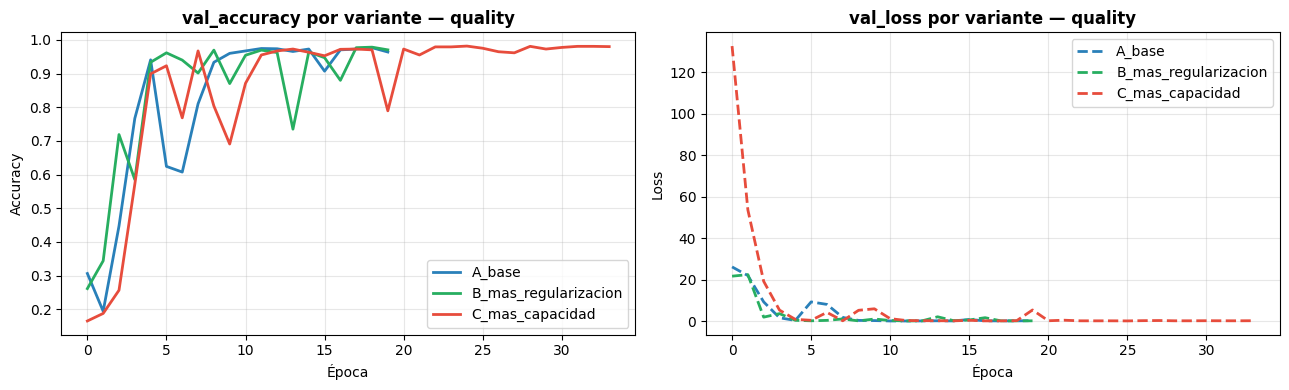

In [9]:
figure_quality, (axis_quality_acc, axis_quality_loss) = plt.subplots(
    1, 2, figsize=(13, 4)
)
variant_colors = {
    "A_base": "#2980b9",
    "B_mas_regularizacion": "#27ae60",
    "C_mas_capacidad": "#e74c3c",
}

for quality_variant_key, quality_history in quality_histories.items():
    axis_quality_acc.plot(
        quality_history.history["val_accuracy"],
        label=quality_variant_key,
        color=variant_colors[quality_variant_key],
        linewidth=2,
    )
    axis_quality_loss.plot(
        quality_history.history["val_loss"],
        label=quality_variant_key,
        color=variant_colors[quality_variant_key],
        linewidth=2,
        linestyle="--",
    )

axis_quality_acc.set_title("val_accuracy por variante — quality",
                           fontweight="bold")
axis_quality_acc.set_xlabel("Época")
axis_quality_acc.set_ylabel("Accuracy")
axis_quality_acc.legend()
axis_quality_acc.grid(alpha=0.3)

axis_quality_loss.set_title("val_loss por variante — quality",
                            fontweight="bold")
axis_quality_loss.set_xlabel("Época")
axis_quality_loss.set_ylabel("Loss")
axis_quality_loss.legend()
axis_quality_loss.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_cnn_variantes_quality.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [10]:
variant_summary_quality = []
for quality_variant_key, quality_history in quality_histories.items():
    best_epoch = int(np.argmax(quality_history.history["val_accuracy"]))
    variant_summary_quality.append({
        "variante": quality_variant_key,
        "descripción": VARIANTS[quality_variant_key]["description"],
        "épocas_entrenadas": len(quality_history.history["val_accuracy"]),
        "mejor_época": best_epoch + 1,
        "val_accuracy": round(max(quality_history.history["val_accuracy"]), 4),
        "val_loss": round(min(quality_history.history["val_loss"]), 4),
    })

df_vs_quality = pd.DataFrame(variant_summary_quality).sort_values(
    "val_accuracy", ascending=False
)
display(df_vs_quality)

best_variant_quality = df_vs_quality.iloc[0]["variante"]
print(f"\n→ Mejor variante para QUALITY: {best_variant_quality}")
print(f"  val_accuracy = {df_vs_quality.iloc[0]['val_accuracy']}")


,variante,descripción,épocas_entrenadas,mejor_época,val_accuracy,val_loss
2,C_mas_capacidad,Mayor capacidad de representación,34,25,0.9816,0.1517
1,B_mas_regularizacion,Más regularización,20,19,0.9784,0.1383
0,A_base,Base,20,19,0.9768,0.1152



→ Mejor variante para QUALITY: C_mas_capacidad
  val_accuracy = 0.9816


## 8. Entrenamiento para tamaño (`size_label`)
 
Repetimos el mismo proceso para la tarea de clasificar tamaño
(small / medium / large). 

In [11]:
size_histories = {}
size_models = {}

for size_variant_key, size_variant_data in VARIANTS.items():
    size_model, size_history = train_variant(
        X_train, y_train_s_int,
        X_val, y_val_s_int,
        variant_key=size_variant_key,
        variant_data=size_variant_data,
        target_name="size",
    )
    size_histories[size_variant_key] = size_history
    size_models[size_variant_key] = size_model



  Tarea: size  |  Variante: A_base
  Base
Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 68s 532ms/step - accuracy: 0.5093 - loss: 1.6906 - val_accuracy: 0.3349 - val_loss: 11.8493 - learning_rate: 0.0010
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 510ms/step - accuracy: 0.5486 - loss: 0.8915 - val_accuracy: 0.3357 - val_loss: 15.6908 - learning_rate: 0.0010
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 61s 518ms/step - accuracy: 0.5921 - loss: 0.8466 - val_accuracy: 0.3790 - val_loss: 7.9237 - learning_rate: 0.0010
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 513ms/step - accuracy: 0.6210 - loss: 0.8072 - val_accuracy: 0.5256 - val_loss: 1.5537 - learning_rate: 0.0010
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 510ms/step - accuracy: 0.6223 - loss: 0.7762 - val_accuracy: 0.6498 - val_loss: 0.8255 - learning_rate: 0.0010
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 502ms/step - accuracy: 0.6506 - loss: 0.7288 - val_accuracy: 0.6498 - val_loss: 1.0186 - learning_rate: 0.0010
Epoch 7/40
117/117 ━━━━━━

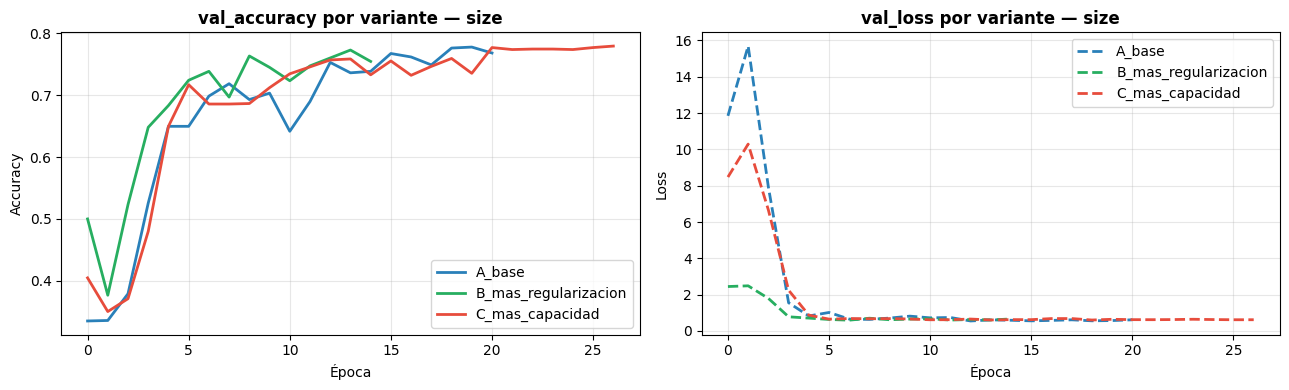

In [12]:
figure_size, (axis_size_acc, axis_size_loss) = plt.subplots(
    1, 2, figsize=(13, 4)
)

for size_variant_key, size_history in size_histories.items():
    axis_size_acc.plot(
        size_history.history["val_accuracy"],
        label=size_variant_key,
        color=variant_colors[size_variant_key],
        linewidth=2,
    )
    axis_size_loss.plot(
        size_history.history["val_loss"],
        label=size_variant_key,
        color=variant_colors[size_variant_key],
        linewidth=2,
        linestyle="--",
    )

axis_size_acc.set_title("val_accuracy por variante — size",
                        fontweight="bold")
axis_size_acc.set_xlabel("Época")
axis_size_acc.set_ylabel("Accuracy")
axis_size_acc.legend()
axis_size_acc.grid(alpha=0.3)

axis_size_loss.set_title("val_loss por variante — size", fontweight="bold")
axis_size_loss.set_xlabel("Época")
axis_size_loss.set_ylabel("Loss")
axis_size_loss.legend()
axis_size_loss.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_cnn_variantes_size.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [13]:
variant_summary_size = []
for size_variant_key, size_history in size_histories.items():
    best_epoch = int(np.argmax(size_history.history["val_accuracy"]))
    variant_summary_size.append({
        "variante": size_variant_key,
        "descripción": VARIANTS[size_variant_key]["description"],
        "épocas_entrenadas": len(size_history.history["val_accuracy"]),
        "mejor_época": best_epoch + 1,
        "val_accuracy": round(max(size_history.history["val_accuracy"]), 4),
        "val_loss": round(min(size_history.history["val_loss"]), 4),
    })

df_vs_size = pd.DataFrame(variant_summary_size).sort_values(
    "val_accuracy", ascending=False
)
display(df_vs_size)

best_variant_size = df_vs_size.iloc[0]["variante"]
print(f"\n→ Mejor variante para SIZE: {best_variant_size}")
print(f"  val_accuracy = {df_vs_size.iloc[0]['val_accuracy']}")


,variante,descripción,épocas_entrenadas,mejor_época,val_accuracy,val_loss
2,C_mas_capacidad,Mayor capacidad de representación,27,27,0.7796,0.6028
0,A_base,Base,21,20,0.7780,0.5498
1,B_mas_regularizacion,Más regularización,15,14,0.7732,0.5942



→ Mejor variante para SIZE: C_mas_capacidad
  val_accuracy = 0.7796


## 9. Curvas de entrenamiento del mejor modelo
 
Graficamos las curvas completas (train vs. val) del mejor modelo
para cada tarea, con el fin de analizar si hay sobreajuste.


── QUALITY ──────────────────────────────────────────────


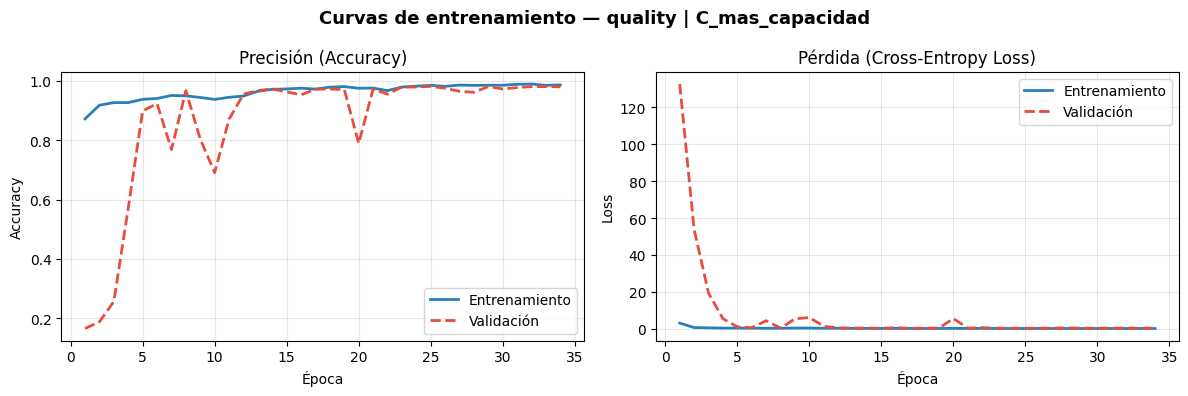

  Train accuracy final : 0.9864
  Mejor val accuracy   : 0.9816
  Gap (train - val)    : 0.0048
  Sin sobreajuste significativo (gap < 5%)

── SIZE ─────────────────────────────────────────────────


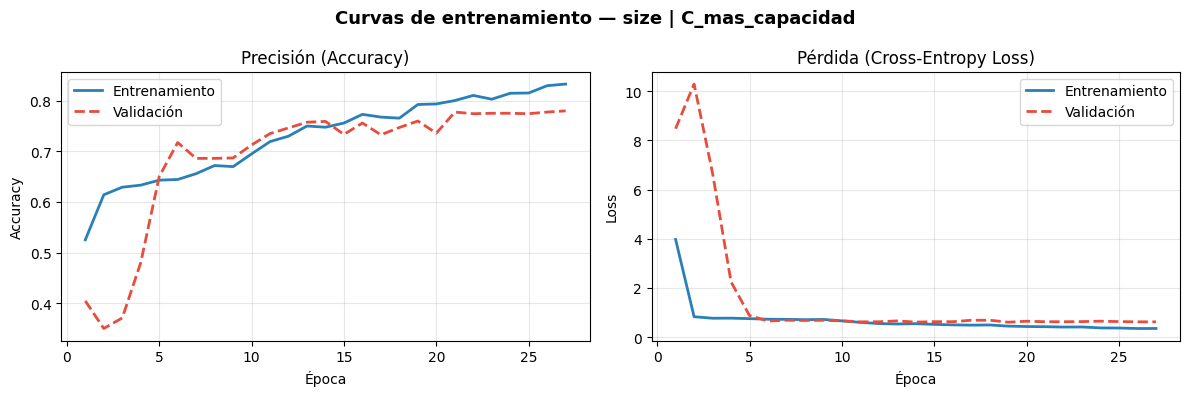

  Train accuracy final : 0.8325
  Mejor val accuracy   : 0.7796
  Gap (train - val)    : 0.0529
  Sobreajuste leve (gap 5-15%)


In [14]:
def plot_training_curves(training_history, target_name,
                         variant_key, save_path):
    curve_figure, (axis_acc, axis_loss) = plt.subplots(
        1, 2, figsize=(12, 4)
    )
    curve_figure.suptitle(
        f"Curvas de entrenamiento — {target_name} | {variant_key}",
        fontsize=13,
        fontweight="bold",
    )

    epochs_range = range(1, len(training_history.history["accuracy"]) + 1)

    axis_acc.plot(
        epochs_range,
        training_history.history["accuracy"],
        label="Entrenamiento",
        color="#2980b9",
        linewidth=2,
    )
    axis_acc.plot(
        epochs_range,
        training_history.history["val_accuracy"],
        label="Validación",
        color="#e74c3c",
        linewidth=2,
        linestyle="--",
    )
    axis_acc.set_title("Precisión (Accuracy)")
    axis_acc.set_xlabel("Época")
    axis_acc.set_ylabel("Accuracy")
    axis_acc.legend()
    axis_acc.grid(alpha=0.3)

    axis_loss.plot(
        epochs_range,
        training_history.history["loss"],
        label="Entrenamiento",
        color="#2980b9",
        linewidth=2,
    )
    axis_loss.plot(
        epochs_range,
        training_history.history["val_loss"],
        label="Validación",
        color="#e74c3c",
        linewidth=2,
        linestyle="--",
    )
    axis_loss.set_title("Pérdida (Cross-Entropy Loss)")
    axis_loss.set_xlabel("Época")
    axis_loss.set_ylabel("Loss")
    axis_loss.legend()
    axis_loss.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    final_train = training_history.history["accuracy"][-1]
    best_val = max(training_history.history["val_accuracy"])
    gap = final_train - best_val
    print(f"  Train accuracy final : {final_train:.4f}")
    print(f"  Mejor val accuracy   : {best_val:.4f}")
    print(f"  Gap (train - val)    : {gap:.4f}")
    if gap < 0.05:
        print("  Sin sobreajuste significativo (gap < 5%)")
    elif gap < 0.15:
        print("  Sobreajuste leve (gap 5-15%)")
    else:
        print("  Sobreajuste detectado (gap > 15%)")

print("\n── QUALITY ──────────────────────────────────────────────")
plot_training_curves(
    quality_histories[best_variant_quality],
    target_name="quality",
    variant_key=best_variant_quality,
    save_path=FIGURES_DIR / "04_curvas_quality.png",
)

print("\n── SIZE ─────────────────────────────────────────────────")
plot_training_curves(
    size_histories[best_variant_size],
    target_name="size",
    variant_key=best_variant_size,
    save_path=FIGURES_DIR / "04_curvas_size.png",
)


## 10. Evaluación final en el conjunto de prueba
 
El conjunto de prueba no se tocó durante el entrenamiento ni la
selección de variantes, ya que es la evaluación definitiva del modelo.

In [15]:
def evaluate_on_test(cnn_model, x_data, y_true_str, label_names,
                     model_name, target_name):
    y_pred_int = np.argmax(cnn_model.predict(x_data, verbose=0), axis=1)
    y_pred_str = np.array([label_names[index] for index in y_pred_int])

    return {
        "target": target_name,
        "dataset": "test",
        "model": model_name,
        "accuracy": round(accuracy_score(y_true_str, y_pred_str), 4),
        "precision_macro": round(precision_score(
            y_true_str, y_pred_str, average="macro",
            zero_division=0, labels=label_names), 4),
        "recall_macro": round(recall_score(
            y_true_str, y_pred_str, average="macro",
            zero_division=0, labels=label_names), 4),
        "f1_macro": round(f1_score(
            y_true_str, y_pred_str, average="macro",
            zero_division=0, labels=label_names), 4),
        "f1_weighted": round(f1_score(
            y_true_str, y_pred_str, average="weighted",
            zero_division=0, labels=label_names), 4),
        "kappa": round(cohen_kappa_score(y_true_str, y_pred_str), 4),
        "labels": ", ".join(label_names),
    }


cnn_rows = []

best_cnn_quality = quality_models[best_variant_quality]
row_q = evaluate_on_test(
    best_cnn_quality,
    X_test,
    y_test_quality,
    QUALITY_LABELS,
    "CNN",
    "quality",
)
cnn_rows.append(row_q)

best_cnn_size = size_models[best_variant_size]
row_s = evaluate_on_test(
    best_cnn_size,
    X_test,
    y_test_size,
    SIZE_LABELS,
    "CNN",
    "size",
)
cnn_rows.append(row_s)

df_cnn_results = pd.DataFrame(cnn_rows)
display(df_cnn_results)


,target,dataset,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,kappa,labels
0,quality,test,CNN,0.9792,0.9794,0.9656,0.9721,0.9790,0.9639,"bad, regular, good"
1,size,test,CNN,0.7758,0.7818,0.7759,0.7779,0.7778,0.6637,"small, medium, large"


In [16]:
test_tasks = [
    ("quality", best_cnn_quality, X_test, y_test_quality,
     QUALITY_LABELS, best_variant_quality),
    ("size", best_cnn_size, X_test, y_test_size,
     SIZE_LABELS, best_variant_size),
]

for target_name, cnn_model, x_data, y_true_str, label_names, variant_key in test_tasks:
    y_pred_int = np.argmax(cnn_model.predict(x_data, verbose=0), axis=1)
    y_pred_str = np.array([label_names[index] for index in y_pred_int])

    print(f"\n{'─'*50}")
    print(f"  Reporte — tarea: {target_name.upper()}")
    print(f"  Variante: {variant_key}")
    print(f"{'─'*50}")
    print(classification_report(
        y_true_str,
        y_pred_str,
        labels=label_names,
        zero_division=0,
    ))



──────────────────────────────────────────────────
  Reporte — tarea: QUALITY
  Variante: C_mas_capacidad
──────────────────────────────────────────────────
              precision    recall  f1-score   support

         bad       0.97      0.91      0.94       206
     regular       0.97      0.99      0.98       705
        good       0.99      0.99      0.99       338

    accuracy                           0.98      1249
   macro avg       0.98      0.97      0.97      1249
weighted avg       0.98      0.98      0.98      1249


──────────────────────────────────────────────────
  Reporte — tarea: SIZE
  Variante: C_mas_capacidad
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       small       0.82      0.80      0.81       416
      medium       0.67      0.73      0.70       417
       large       0.86      0.79      0.82       416

    accuracy                           0.78      1249
   macro avg       0.78      0.78 

## 11. Matrices de confusión
 


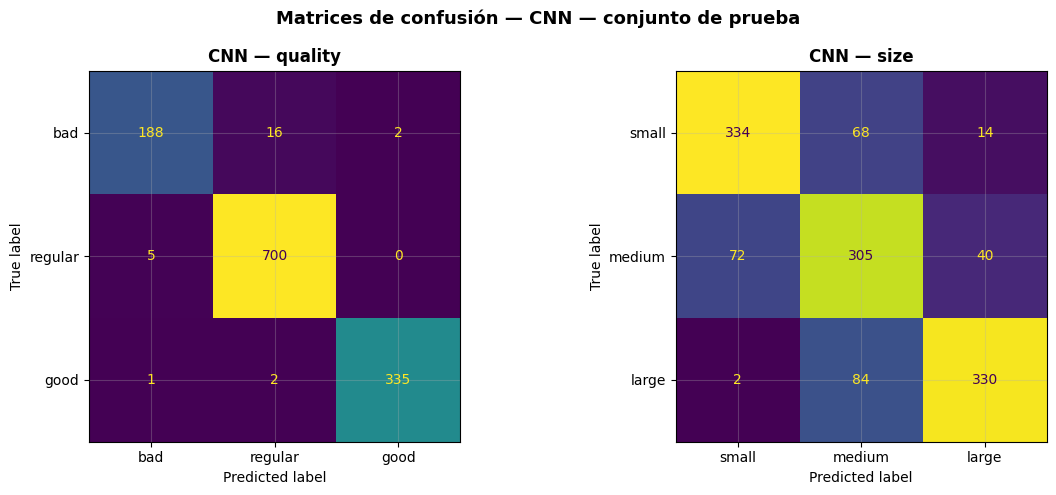

In [17]:
confusion_figure, confusion_axes = plt.subplots(1, 2, figsize=(12, 5))
confusion_figure.suptitle(
    "Matrices de confusión — CNN — conjunto de prueba",
    fontsize=13,
    fontweight="bold",
)

confusion_tasks = [
    (confusion_axes[0], "quality", best_cnn_quality,
     X_test, y_test_quality, QUALITY_LABELS),
    (confusion_axes[1], "size", best_cnn_size,
     X_test, y_test_size, SIZE_LABELS),
]

for axis, target_name, cnn_model, x_data, y_true_str, label_names in confusion_tasks:
    y_pred_int = np.argmax(cnn_model.predict(x_data, verbose=0), axis=1)
    y_pred_str = np.array([label_names[index] for index in y_pred_int])

    ConfusionMatrixDisplay.from_predictions(
        y_true_str,
        y_pred_str,
        labels=label_names,
        normalize=None,
        colorbar=False,
        ax=axis,
    )
    axis.set_title(f"CNN — {target_name}", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_confusion_cnn.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Visualización de mapas de características
 
Lo utilizamos para visualizar las características extraídas por la CNN y comprender qué patrones visuales son considerados por el modelo durante el proceso de clasificación.

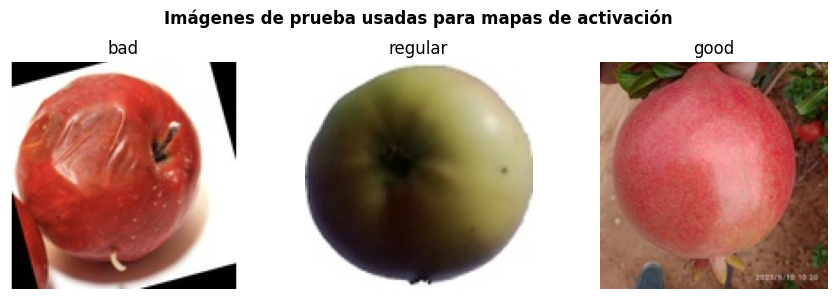

In [18]:
activation_figure, activation_axes = plt.subplots(1, 3, figsize=(9, 3))
activation_figure.suptitle(
    "Imágenes de prueba usadas para mapas de activación",
    fontweight="bold",
)

sample_imgs = {}
for class_index, class_name in enumerate(QUALITY_LABELS):
    class_mask = y_test_quality == class_name
    if class_mask.sum() == 0:
        sample_index = 0
    else:
        sample_index = np.where(class_mask)[0][0]
    sample_imgs[class_name] = X_test[sample_index]
    activation_axes[class_index].imshow(X_test[sample_index])
    activation_axes[class_index].set_title(class_name)
    activation_axes[class_index].axis("off")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_muestras_activacion.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()


Capas convolucionales disponibles:
  0: conv2d_9
  1: conv2d_10
  2: conv2d_11


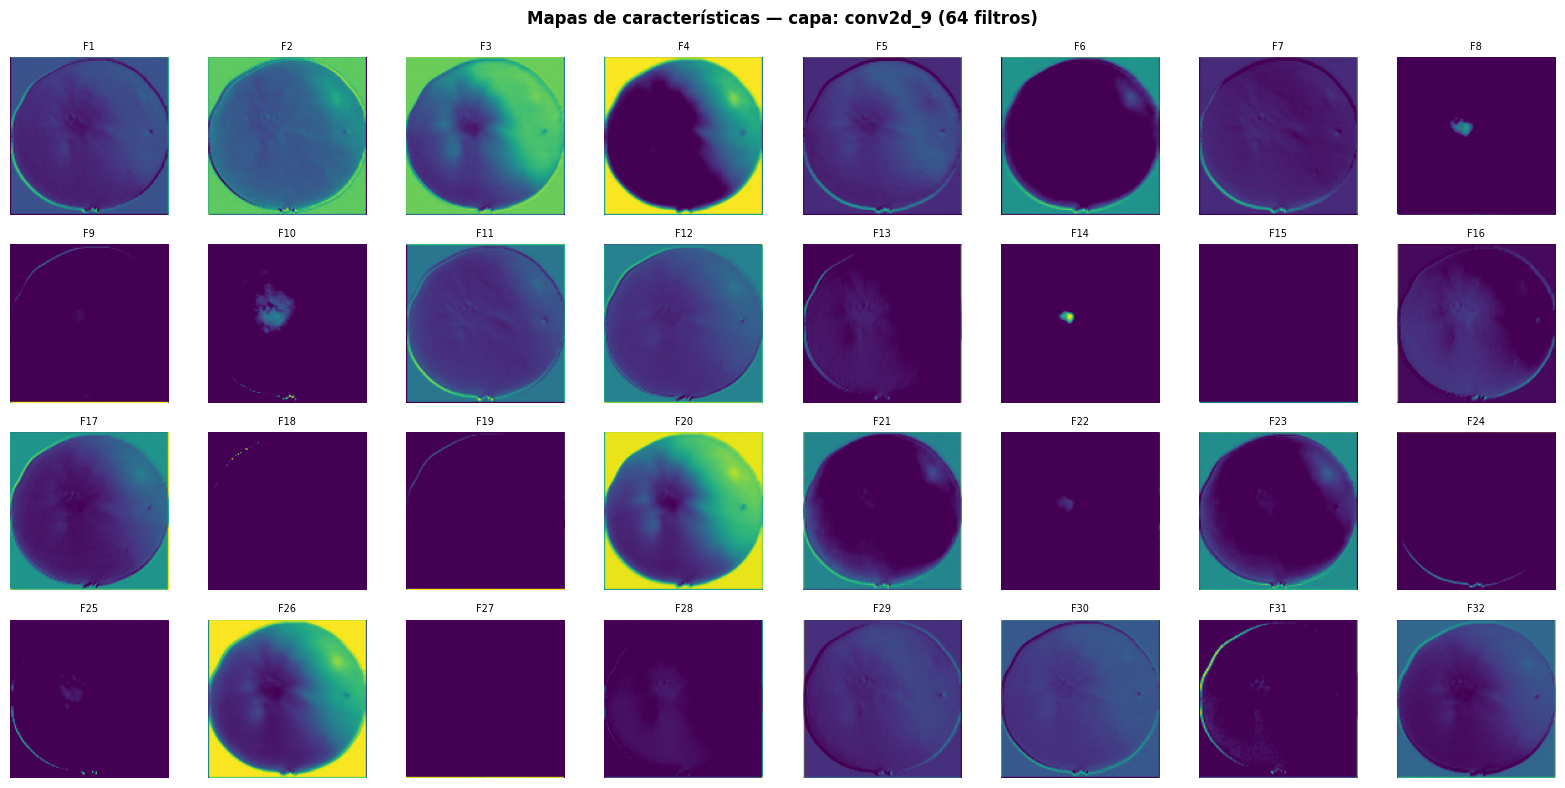

  Capa conv2d_9: activaciones con forma (128, 128, 64)


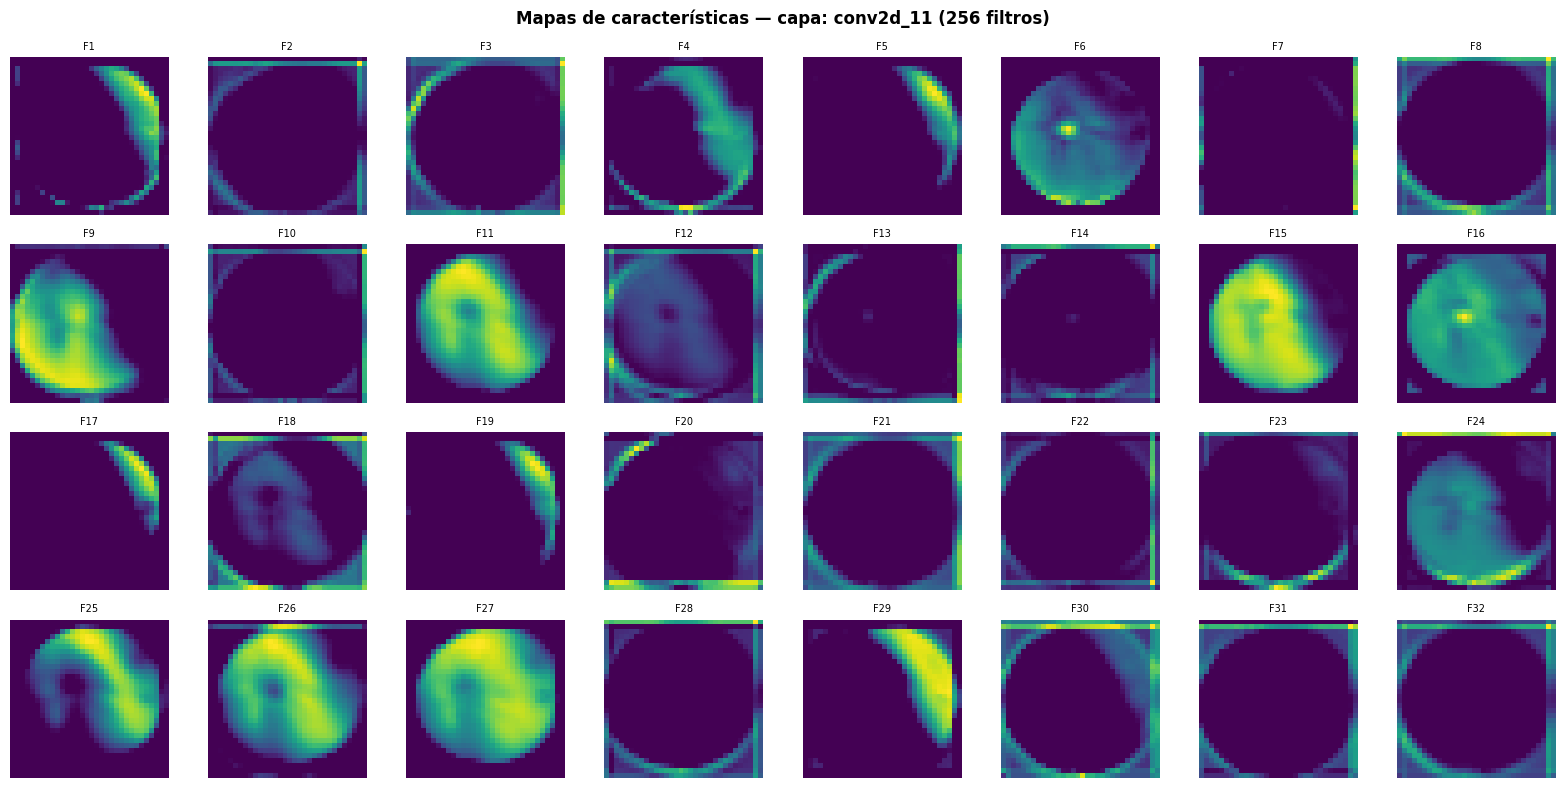

  Capa conv2d_11: activaciones con forma (32, 32, 256)


In [19]:
conv_layer_names = [
    layer.name for layer in best_cnn_quality.layers
    if "conv2d" in layer.name
]
print("Capas convolucionales disponibles:")
for layer_index, layer_name in enumerate(conv_layer_names):
    print(f"  {layer_index}: {layer_name}")

layers_to_show = [conv_layer_names[0], conv_layer_names[-1]]

for selected_layer_name in layers_to_show:
    selected_layer = best_cnn_quality.get_layer(selected_layer_name)
    activation_model = Model(
        inputs=best_cnn_quality.input,
        outputs=selected_layer.output,
    )

    test_img = sample_imgs[QUALITY_LABELS[len(QUALITY_LABELS) // 2]]
    img_batch = np.expand_dims(test_img, axis=0)
    activations = activation_model.predict(img_batch, verbose=0)

    filter_count = activations.shape[-1]
    filters_to_show = min(filter_count, 32)
    column_count = 8
    row_count = int(np.ceil(filters_to_show / column_count))

    feature_figure, feature_axes = plt.subplots(
        row_count,
        column_count,
        figsize=(16, 2 * row_count),
    )
    feature_figure.suptitle(
        f"Mapas de características — capa: {selected_layer_name} "
        f"({filter_count} filtros)",
        fontsize=12,
        fontweight="bold",
    )

    for filter_index in range(filters_to_show):
        feature_axis = feature_axes.flat[filter_index]
        feature_axis.imshow(
            activations[0, :, :, filter_index],
            cmap="viridis",
        )
        feature_axis.axis("off")
        feature_axis.set_title(f"F{filter_index + 1}", fontsize=7)

    for empty_axis_index in range(filters_to_show, row_count * column_count):
        feature_axes.flat[empty_axis_index].axis("off")

    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"04_activaciones_{selected_layer_name}.png",
        dpi=100,
        bbox_inches="tight",
    )
    plt.show()

    print(
        f"  Capa {selected_layer_name}: "
        f"activaciones con forma {activations.shape[1:]}"
    )


## 13. Guardar modelos

In [20]:
def save_cnn(cnn_model, target_name, label_names, variant_key):
    model_path = MODELS_DIR / f"cnn_{target_name}.keras"
    config_path = MODELS_DIR / f"cnn_{target_name}_config.json"

    cnn_model.save(model_path)

    config = {
        "task": target_name,
        "target": target_name,
        "classes": label_names,
        "labels": label_names,
        "img_size": [IMG_SIZE, IMG_SIZE],
        "image_size": [IMG_SIZE, IMG_SIZE],
        "color_mode": "RGB",
        "scale": 255.0,
        "flatten": False,
        "model_family": "cnn",
        "variant": variant_key,
        "preprocessing": "ImageOps.pad, RGB, 128x128, numpy array, scale /255",
    }
    config_path.write_text(
        json.dumps(config, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"  Modelo guardado : {model_path.relative_to(PROJECT_ROOT)}")
    print(f"  Config guardado : {config_path.relative_to(PROJECT_ROOT)}")
    return model_path, config_path


print("Guardando modelos CNN…")
save_cnn(best_cnn_quality, "quality", QUALITY_LABELS, best_variant_quality)
save_cnn(best_cnn_size, "size", SIZE_LABELS, best_variant_size)


Guardando modelos CNN…
  Modelo guardado : models\cnn_quality.keras
  Config guardado : models\cnn_quality_config.json
  Modelo guardado : models\cnn_size.keras
  Config guardado : models\cnn_size_config.json


(WindowsPath('C:/Users/renzi/PycharmProjects/proyecto-final-apo-3/models/cnn_size.keras'),
 WindowsPath('C:/Users/renzi/PycharmProjects/proyecto-final-apo-3/models/cnn_size_config.json'))

## 14. Comparación final: CNN vs. modelos de Machine Learning
 

In [21]:
nb03_path = TABLES_DIR / "03_model_comparison.csv"
 
if nb03_path.exists():
    df_nb03 = pd.read_csv(nb03_path)
    df_nb03_test = df_nb03[df_nb03["dataset"] == "test"].copy()

    df_all = pd.concat([df_nb03_test, df_cnn_results], ignore_index=True)
else:
    print("Ejecuta primero el Notebook 03 para ver la comparación completa.")
    df_all = df_cnn_results.copy()
 
cols_show = ["target", "model", "accuracy", "f1_macro",
             "f1_weighted", "kappa"]
df_display = df_all[[c for c in cols_show if c in df_all.columns]].copy()
df_display = df_display.sort_values(["target", "f1_macro"], ascending=[True, False])
display(df_display)
 
full_comparison_path = TABLES_DIR / "04_comparacion_final.csv"
df_all.to_csv(full_comparison_path, index=False, encoding="utf-8")
print(f"\\nTabla guardada en: {full_comparison_path.relative_to(PROJECT_ROOT)}")

,target,model,accuracy,f1_macro,f1_weighted,kappa
6,quality,CNN,0.9792,0.9721,0.9790,0.9639
2,quality,Random Forest,0.9584,0.9465,0.9582,0.9279
3,quality,SVM lineal,0.8927,0.8583,0.8917,0.8153
0,quality,Baseline mayoría,0.5645,0.2405,0.4073,0.0000
7,size,CNN,0.7758,0.7779,0.7778,0.6637
4,size,Random Forest,0.7582,0.7582,0.7582,0.6373
5,size,SVM lineal,0.6709,0.6696,0.6695,0.5064
1,size,Baseline mayoría,0.3331,0.1666,0.1664,0.0000


\nTabla guardada en: results\tables\04_comparacion_final.csv


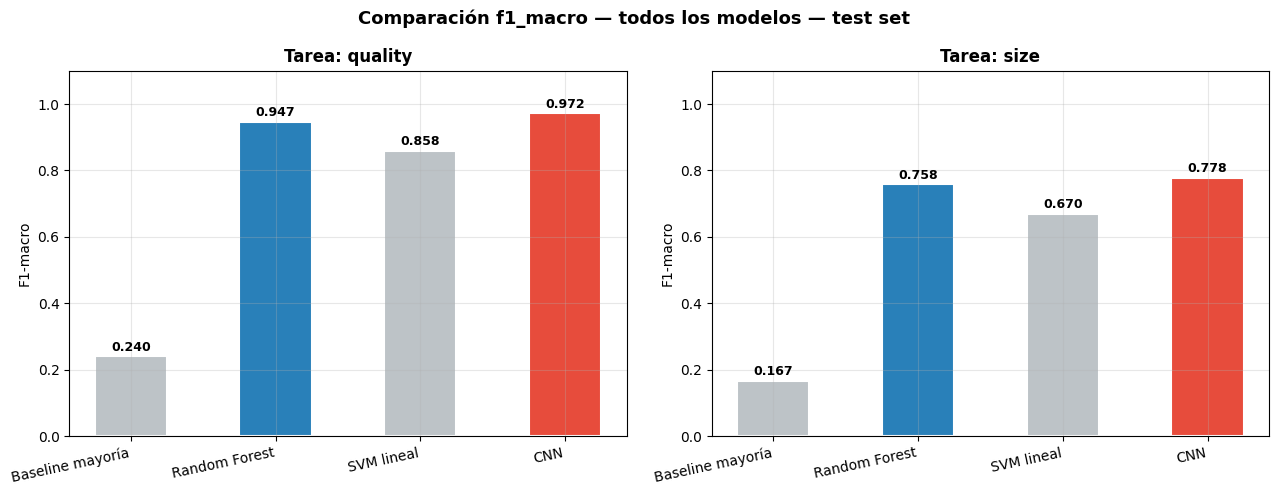

In [22]:
if nb03_path.exists():
    comparison_figure, comparison_axes = plt.subplots(1, 2, figsize=(13, 5))
    comparison_figure.suptitle(
        "Comparación f1_macro — todos los modelos — test set",
        fontsize=13,
        fontweight="bold",
    )

    model_colors = {
        "Baseline": "#95a5a6",
        "Random Forest": "#2980b9",
        "SVM": "#8e44ad",
        "CNN": "#e74c3c",
    }

    for comparison_axis, target_name in zip(comparison_axes, ["quality", "size"]):
        task_subset = df_all[df_all["target"] == target_name].copy()
        model_order = ["Baseline mayoría", "Random Forest", "SVM lineal", "CNN"]
        task_subset = task_subset.set_index("model").reindex(
            [model_name for model_name in model_order
             if model_name in task_subset["model"].values]
        ).reset_index()

        bar_colors = [
            model_colors.get(model_name, "#bdc3c7")
            for model_name in task_subset["model"]
        ]
        bars = comparison_axis.bar(
            task_subset["model"],
            task_subset["f1_macro"],
            color=bar_colors,
            edgecolor="white",
            linewidth=1.5,
            width=0.5,
        )

        for bar_item in bars:
            comparison_axis.text(
                bar_item.get_x() + bar_item.get_width() / 2,
                bar_item.get_height() + 0.008,
                f"{bar_item.get_height():.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

        comparison_axis.set_title(f"Tarea: {target_name}", fontweight="bold")
        comparison_axis.set_ylabel("F1-macro")
        comparison_axis.set_ylim(0, 1.1)
        comparison_axis.set_xticks(range(len(task_subset["model"])))
        comparison_axis.set_xticklabels(
            task_subset["model"],
            rotation=12,
            ha="right",
        )
        comparison_axis.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "04_comparacion_final.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
